# GIT dependency (colab only)


In [ ]:
# Run if LOCAL
# %cd ../
# !git clone https://github.com/MiguelPartosa/Thesis-FOS-BinaryClass-WSD.git
# %cd Thesis-FOS-BinaryClass-WSD/Ensemble Model/

# or if already cloned in root
# %cd ../Thesis-FOS-BinaryClass-WSD/Ensemble Model/

c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\Thesis-FOS-BinaryClass-WSD\Ensemble Model


c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
!git clone https://github.com/MiguelPartosa/Thesis-FOS-BinaryClass-WSD.git
%cd Thesis-FOS-BinaryClass-WSD/Ensemble Model/

[WinError 3] The system cannot find the path specified: 'Thesis-FOS-BinaryClass-WSD/Ensemble Model/'
c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\Thesis-FOS-BinaryClass-WSD\Ensemble Model


c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


# Load Models and Libraries


In [3]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

## Sentence Transformer -- Sentence Embeddings


In [4]:
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer('sentence-transformers/LaBSE')

c:\Users\Miguel\Documents\Project Source Files\IT Work\School\Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Processing


## Load Dataset


In [5]:
df_test = pd.read_excel('../../Dataset/Test_Set_WLabels.xlsx')
df_train = pd.read_excel('../../Dataset/Train_Set_WLabels.xlsx')
display(df_test.head(1), df_test.shape, df_train.head(1), df_train.shape)

,FOS,Word Sense,Verb,Usage,Is FOS
0,makabuhi og patay,usa ka makapatikod nga bakak o sugilanon,"['makabuhi', 'patay']",Ang mga tawo nga makabuhi og patay kasagaran m...,1


(240, 5)

,FOS,Word Sense,Verb,Usage,Is FOS
0,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']","Si Pedro kakha tuka, walay savings ug pirmi la...",1


(960, 5)

## Sentence Transformer


Removing the label column from the dataset for clarity


In [6]:
# df_train.drop(columns=['Is FOS'], inplace=True)
df = df_train.copy()

In [7]:
# df['Word Sense'] = df['Word Sense']
df.head(3)

,FOS,Word Sense,Verb,Usage,Is FOS
0,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']","Si Pedro kakha tuka, walay savings ug pirmi la...",1
1,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']",Ang langgam nagkakha tuka sa yuta aron makakao...,0
2,ipanabi na sa clouds,Isulti kana sa mga marine,['ipanabi'],Ang mga tawo nga magbuot-buot pirmi lang ipana...,1


The embeddings are explicitly normalized so that


### Generate Embeddings and Similarity Columns


> An alteration from the previously shown way of retrieving the embeddings are its normalization to work with PCA and containing all the new columns to be generated from embeddings and similarity score into one function.


In [8]:
def GetEmbeddings(words: str) -> np.ndarray:
    return embedding_model.encode(words, normalize_embeddings=True)


def ComputeSimilarity(embedding1, embedding2):
    return embedding_model.similarity(embedding1, embedding2)

In [9]:
def RetrieveEmbeddings(df) -> pd.DataFrame:
    df_embeddings = df.copy()
    df_embeddings['Sentence Embeddings'] = df['Word Sense'].apply(
        GetEmbeddings)
    df_embeddings['Verb Embeddings'] = df['Verb'].apply(GetEmbeddings)
    df_embeddings['Usage Embeddings'] = df['Usage'].apply(GetEmbeddings)
    df_embeddings['Similarity Scores'] = df_embeddings.apply(lambda row: ComputeSimilarity(
        row['Sentence Embeddings'], row['Usage Embeddings']), axis=1)
    return df_embeddings


df_embedded = RetrieveEmbeddings(df)
df_embedded.head(3)

,FOS,Word Sense,Verb,Usage,Is FOS,Sentence Embeddings,Verb Embeddings,Usage Embeddings,Similarity Scores
0,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']","Si Pedro kakha tuka, walay savings ug pirmi la...",1,"[0.03480861, -0.039900906, 0.0122562805, -0.01...","[0.0033358778, -0.013116839, -0.058490533, -0....","[-0.06521839, -0.011564791, -0.07741037, 0.038...",[[tensor(0.1349)]]
1,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']",Ang langgam nagkakha tuka sa yuta aron makakao...,0,"[0.03480861, -0.039900906, 0.0122562805, -0.01...","[0.0033358778, -0.013116839, -0.058490533, -0....","[-0.065647416, 0.0007023677, -0.010165986, 0.0...",[[tensor(0.1166)]]
2,ipanabi na sa clouds,Isulti kana sa mga marine,['ipanabi'],Ang mga tawo nga magbuot-buot pirmi lang ipana...,1,"[-0.0230799, 0.008441078, 0.012099509, -0.0519...","[-0.019613665, 0.010178943, 0.012024134, -0.04...","[-0.026708158, -0.065387964, 0.048197918, 0.00...",[[tensor(0.1359)]]


In [10]:
df_embedded.to_excel(
    '../../Dataset/Ensemble/train_with_embeddings.xlsx', index=False)

## Checkpoint for dataset


In [11]:
df_embedded = pd.read_excel(
    '../../Dataset/Ensemble/train_with_embeddings.xlsx')
df_embedded.head(1)

,FOS,Word Sense,Verb,Usage,Is FOS,Sentence Embeddings,Verb Embeddings,Usage Embeddings,Similarity Scores
0,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']","Si Pedro kakha tuka, walay savings ug pirmi la...",1,[ 3.48086096e-02 -3.99009064e-02 1.22562805e-...,[ 3.33587779e-03 -1.31168393e-02 -5.84905334e-...,[-0.06521839 -0.01156479 -0.07741037 0.038842...,tensor([[0.1349]])


Turning our formatted embeddings as strings back into the original tensor format


In [12]:
def ConvertToNp(string_tensor):
    return np.fromstring(string_tensor.strip("[]"), sep=" ")


df_embedded['Sentence Embeddings'] = df_embedded['Sentence Embeddings'].apply(
    ConvertToNp)
df_embedded['Verb Embeddings'] = df_embedded['Verb Embeddings'].apply(
    ConvertToNp)
df_embedded['Usage Embeddings'] = df_embedded['Usage Embeddings'].apply(
    ConvertToNp)

# Checking to see if the columns are successfully converted
display(type(df_embedded.iloc[0, 5]), type(
    df_embedded.iloc[0, 6]), type(df_embedded.iloc[0, 7]))

numpy.ndarray

numpy.ndarray

numpy.ndarray

## PCA-Guided K-means


### Transforming Embeddings Columns

- Before taking the embeddings as input for the dimensionality reduction using PCA, we must turn the embeddings columns to dataframes with the size of `(1288,768)` each


In [13]:
def GeneratePCA(col_name: str, col_val: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame()
    # To visualize the transformation
    for col in tqdm(col_val, desc=f'Transforming embeddings for {col_name}'):
        new_row_val = []
        new_row_column_name = []
        for idx, embedding in enumerate(col):
            new_row_column_name.append(str(col_name + f' {idx + 1}'))
            new_row_val.append(embedding)
        df = pd.concat([df,
                        pd.DataFrame(
                            [new_row_val], columns=new_row_column_name)
                        ])
    return df.reset_index(drop=True)


# We make three dataframes for each embedding column
df_pca_sentence = pd.DataFrame(GeneratePCA(
    'Sentence Embeddings', df_embedded['Sentence Embeddings']))
df_pca_verb = pd.DataFrame(GeneratePCA(
    'Verb Embeddings', df_embedded['Verb Embeddings']))
df_pca_usage = pd.DataFrame(GeneratePCA(
    'Usage Embeddings', df_embedded['Usage Embeddings']))
display(df_pca_sentence.head(3), df_pca_usage.head(3), df_pca_verb.head(3))

Transforming embeddings for Usage Embeddings: 100%|██████████| 960/960 [00:07<00:00, 136.35it/s]


,Sentence Embeddings 1,Sentence Embeddings 2,Sentence Embeddings 3,Sentence Embeddings 4,Sentence Embeddings 5,Sentence Embeddings 6,Sentence Embeddings 7,Sentence Embeddings 8,Sentence Embeddings 9,Sentence Embeddings 10,...,Sentence Embeddings 759,Sentence Embeddings 760,Sentence Embeddings 761,Sentence Embeddings 762,Sentence Embeddings 763,Sentence Embeddings 764,Sentence Embeddings 765,Sentence Embeddings 766,Sentence Embeddings 767,Sentence Embeddings 768
0,0.034809,-0.039901,0.012256,-0.017057,-0.022921,-0.032162,-0.007766,-0.024359,-0.019047,-0.052124,...,0.057040,0.011843,-0.015334,-0.043449,0.001799,0.010406,-0.03820,0.062978,-0.020756,-0.009009
1,0.034809,-0.039901,0.012256,-0.017057,-0.022921,-0.032162,-0.007766,-0.024359,-0.019047,-0.052124,...,0.057040,0.011843,-0.015334,-0.043449,0.001799,0.010406,-0.03820,0.062978,-0.020756,-0.009009
2,-0.023080,0.008441,0.012100,-0.051978,0.011383,-0.010438,0.015744,-0.021778,-0.061894,-0.025789,...,-0.030046,-0.029550,0.039228,0.015255,-0.032321,0.010476,0.03558,0.008199,0.002993,-0.007173


,Usage Embeddings 1,Usage Embeddings 2,Usage Embeddings 3,Usage Embeddings 4,Usage Embeddings 5,Usage Embeddings 6,Usage Embeddings 7,Usage Embeddings 8,Usage Embeddings 9,Usage Embeddings 10,...,Usage Embeddings 759,Usage Embeddings 760,Usage Embeddings 761,Usage Embeddings 762,Usage Embeddings 763,Usage Embeddings 764,Usage Embeddings 765,Usage Embeddings 766,Usage Embeddings 767,Usage Embeddings 768
0,-0.065218,-0.011565,-0.077410,0.038843,-0.074321,-0.021441,-0.036264,0.002481,0.030489,0.025514,...,-0.022818,0.063779,0.031201,0.000590,0.042231,0.028850,0.002951,-0.022180,-0.045643,0.026281
1,-0.065647,0.000702,-0.010166,0.003348,-0.037286,0.026068,0.015105,-0.040588,-0.055040,-0.006324,...,-0.051903,0.053916,0.055008,0.004704,0.037570,0.056728,-0.052802,0.000755,-0.006545,-0.046332
2,-0.026708,-0.065388,0.048198,0.006815,0.038396,-0.004726,-0.011711,-0.058304,-0.054648,0.048140,...,-0.009883,0.013690,0.006778,-0.011231,-0.062144,0.012320,-0.025566,0.025425,-0.048099,0.004987


,Verb Embeddings 1,Verb Embeddings 2,Verb Embeddings 3,Verb Embeddings 4,Verb Embeddings 5,Verb Embeddings 6,Verb Embeddings 7,Verb Embeddings 8,Verb Embeddings 9,Verb Embeddings 10,...,Verb Embeddings 759,Verb Embeddings 760,Verb Embeddings 761,Verb Embeddings 762,Verb Embeddings 763,Verb Embeddings 764,Verb Embeddings 765,Verb Embeddings 766,Verb Embeddings 767,Verb Embeddings 768
0,0.003336,-0.013117,-0.058491,-0.052000,-0.025834,-0.024060,-0.035622,0.020816,-0.074262,-0.051879,...,-0.048128,0.027175,-0.013142,0.056867,-0.000643,-0.038617,-0.011111,0.025456,-0.023468,0.020633
1,0.003336,-0.013117,-0.058491,-0.052000,-0.025834,-0.024060,-0.035622,0.020816,-0.074262,-0.051879,...,-0.048128,0.027175,-0.013142,0.056867,-0.000643,-0.038617,-0.011111,0.025456,-0.023468,0.020633
2,-0.019614,0.010179,0.012024,-0.041085,-0.028724,-0.047106,-0.027757,-0.020107,-0.065876,-0.040017,...,-0.022755,0.017941,0.009235,0.043734,0.013993,-0.055346,-0.001796,0.004561,-0.038001,-0.043632


#### Combining Embeddings

Combined plot for the embeddings


In [14]:
df_combined_embeddings = df_pca_verb.join(df_pca_usage.join(df_pca_sentence))
df_combined_embeddings.head(3)

,Verb Embeddings 1,Verb Embeddings 2,Verb Embeddings 3,Verb Embeddings 4,Verb Embeddings 5,Verb Embeddings 6,Verb Embeddings 7,Verb Embeddings 8,Verb Embeddings 9,Verb Embeddings 10,...,Sentence Embeddings 759,Sentence Embeddings 760,Sentence Embeddings 761,Sentence Embeddings 762,Sentence Embeddings 763,Sentence Embeddings 764,Sentence Embeddings 765,Sentence Embeddings 766,Sentence Embeddings 767,Sentence Embeddings 768
0,0.003336,-0.013117,-0.058491,-0.052000,-0.025834,-0.024060,-0.035622,0.020816,-0.074262,-0.051879,...,0.057040,0.011843,-0.015334,-0.043449,0.001799,0.010406,-0.03820,0.062978,-0.020756,-0.009009
1,0.003336,-0.013117,-0.058491,-0.052000,-0.025834,-0.024060,-0.035622,0.020816,-0.074262,-0.051879,...,0.057040,0.011843,-0.015334,-0.043449,0.001799,0.010406,-0.03820,0.062978,-0.020756,-0.009009
2,-0.019614,0.010179,0.012024,-0.041085,-0.028724,-0.047106,-0.027757,-0.020107,-0.065876,-0.040017,...,-0.030046,-0.029550,0.039228,0.015255,-0.032321,0.010476,0.03558,0.008199,0.002993,-0.007173


### Correlation Plot

- To address the comment/suggestion made by Engr. Andrei Martin P. Diamante during the 50% implementation defense, a correlation matrix will show the necessity of include a correlation of the columns from the embeddings


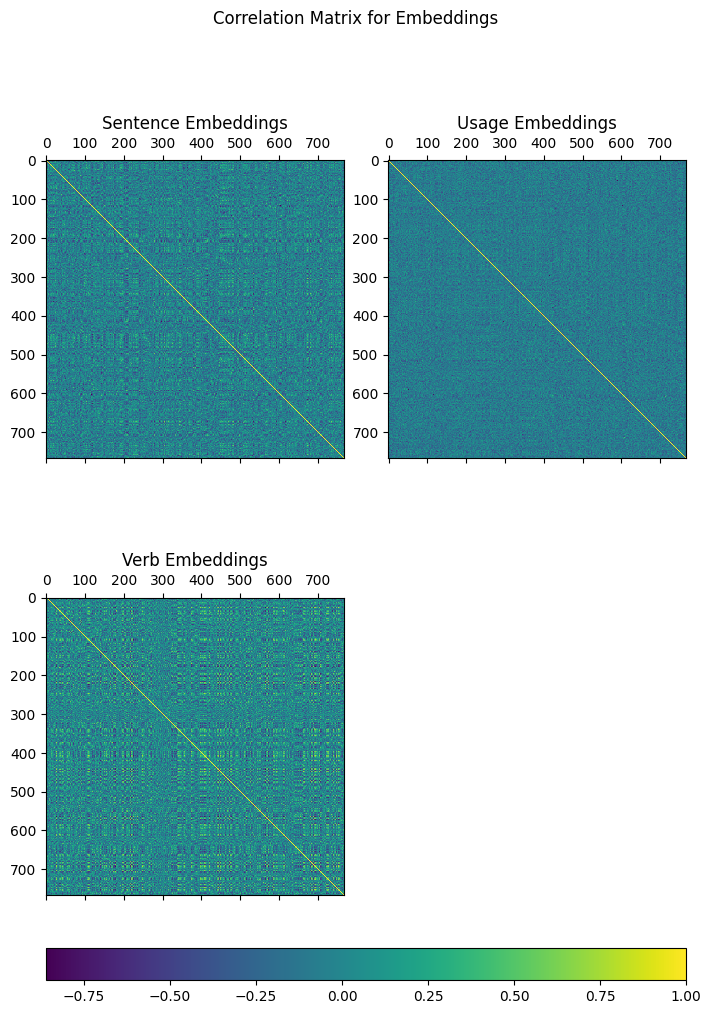

In [15]:

from matplotlib import colors
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

fig, axs = plt.subplots(2, 2, figsize=(7, 10), layout='constrained')

# ColorBar


# datasets will contain all the values of the embeddings dataframes in one numpy array
datasets = [np.concatenate((df_pca_sentence.corr().to_numpy(),
            df_pca_verb.corr().to_numpy(),
            df_pca_usage.corr().to_numpy()), axis=1)]
# create a single norm to be shared across all images

norm = colors.Normalize(vmin=np.min(datasets), vmax=np.max(datasets))
images = []
for ax, data in zip(axs.flat, datasets):
    images.append(ax.imshow(data, norm=norm))

fig.colorbar(images[0], ax=axs, orientation='horizontal', fraction=.1)

def PlotCorrelationMatrix(df, title:str, position:tuple):
    axs[*position].matshow(pd.DataFrame(scaler.fit_transform(df)).corr())
    axs[*position].set_title(f'{title} Embeddings')

PlotCorrelationMatrix(df_pca_sentence, title='Sentence', position=(0,0))
PlotCorrelationMatrix(df_pca_verb, title='Verb', position=(1,0))
PlotCorrelationMatrix(df_pca_usage, title='Usage', position=(0,1))

axs[1, 1].axis('off')

fig.suptitle('Correlation Matrix for Embeddings')

plt.show()

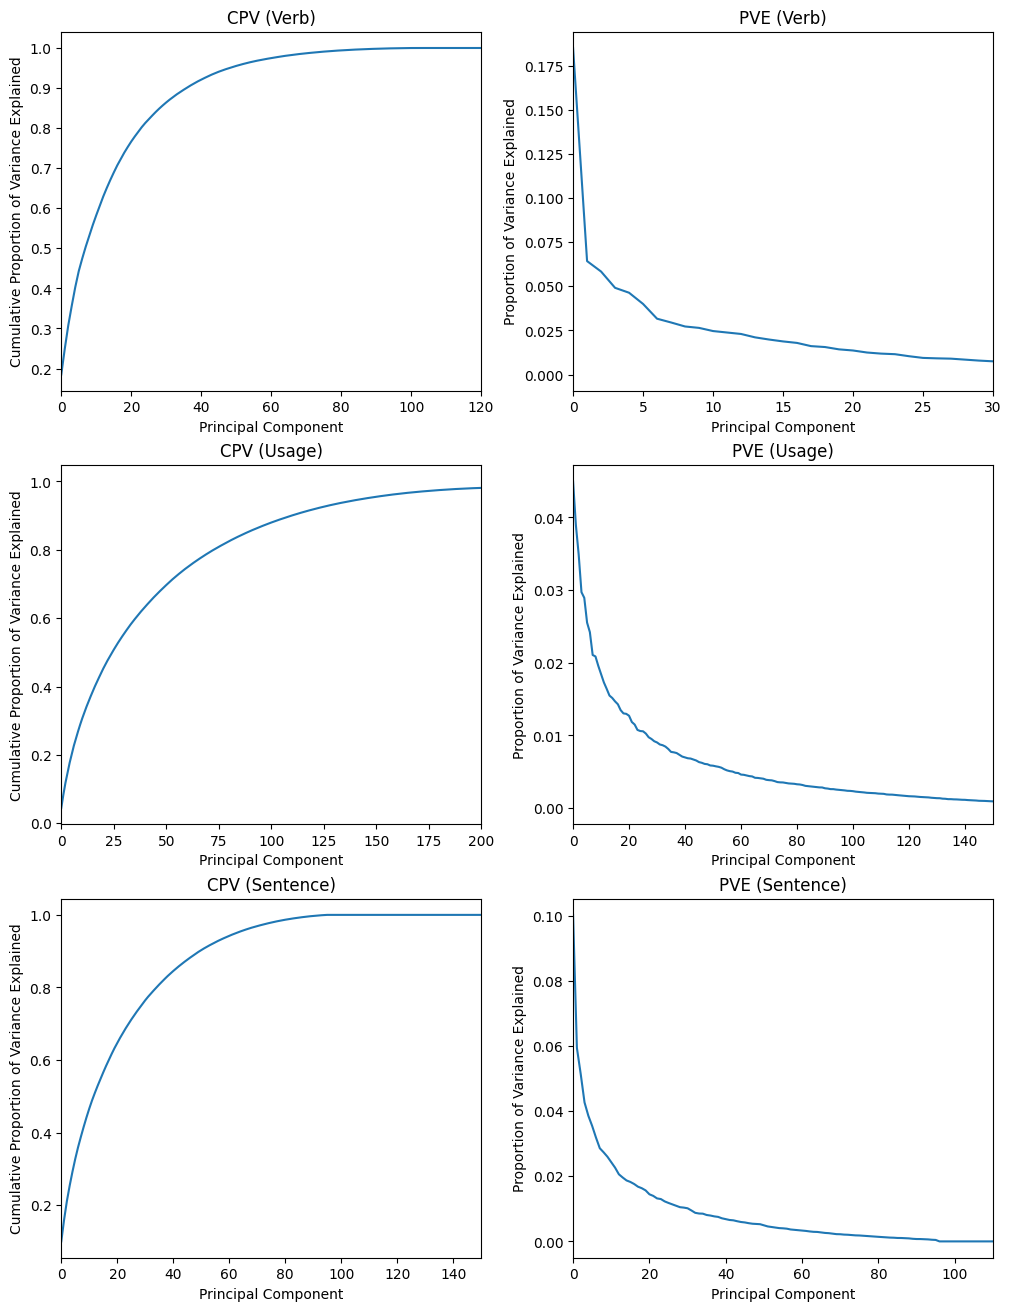

In [16]:
from sklearn.decomposition import PCA
pca = PCA()


def GetExplainedVariance(df):
    raw_scaled = scaler.fit_transform(df)
    pca.fit(raw_scaled)
    return pca.explained_variance_ratio_


def GetCumulativeVariance(df):
    return np.cumsum(GetExplainedVariance(df))


fig, axs = plt.subplots(3, 2, figsize=(10, 13), layout='constrained')


def PlotVariance(df, title: str, row: int, xlim_proportion: int = None, xlim_cumulative: int = None):
    # Plot 1 cumulative var     
    axs[row, 0].plot(GetCumulativeVariance(df))
    axs[row, 0].set_title(
        f'CPV ({title})')
    if xlim_cumulative is not None:
        axs[row, 0].set_xlim(left=0,right=xlim_cumulative)
    axs[row, 0].set_ylabel("Cumulative Proportion of Variance Explained")
    axs[row, 0].set_xlabel("Principal Component")
    
    # Plot 2 explained var
    axs[row, 1].plot(GetExplainedVariance(df))
    axs[row, 1].set_title(f'PVE ({title})')
    if xlim_proportion is not None:
        axs[row, 1].set_xlim(left=0,right=xlim_proportion)
    axs[row, 1].set_ylabel("Proportion of Variance Explained")
    axs[row, 1].set_xlabel("Principal Component")


# Verb Embeddings
PlotVariance(df_pca_verb, row=0, title='Verb', xlim_cumulative=120, xlim_proportion=30)
PlotVariance(df_pca_usage, row=1, title='Usage', xlim_cumulative=200, xlim_proportion=150)
PlotVariance(df_pca_sentence, row=2, title='Sentence', xlim_cumulative=150, xlim_proportion=110)

plt.show()

In [17]:
pd.DataFrame(GetExplainedVariance(df_pca_verb))

,0
0,1.850984e-01
1,6.428751e-02
2,5.837079e-02
3,4.914070e-02
4,4.635834e-02
...,...
763,1.585299e-34
764,1.399540e-34
765,6.645406e-35
766,2.472956e-35


In [18]:
def ShowExplainedProportion(df, idx, title):
    return f"{idx} Components for {title} Embeddings account for {pd.DataFrame(GetExplainedVariance(df)).iloc[idx-1].item():.5f}% of Variability" 

display(
    ShowExplainedProportion(df_pca_verb, 1, 'Verb'),
    ShowExplainedProportion(df_pca_usage, 1, 'Usage'),
    ShowExplainedProportion(df_pca_sentence, 1, 'Sentence'),
)

'1 Components for Verb Embeddings account for 0.18510% of Variability'

'1 Components for Usage Embeddings account for 0.04497% of Variability'

'1 Components for Sentence Embeddings account for 0.10032% of Variability'

In [19]:
def GetIndexOfProportion(df, value, title):
    df_index = pd.DataFrame(GetCumulativeVariance(df)).loc[lambda df: df[0] > value].idxmin().item()
    return f"Index {df_index} or {df_index + 1} number of principal components for {title} has a cumulutive proportion variance {value}> with a value of {pd.DataFrame(GetCumulativeVariance(df)).iloc[df_index].item()}" 

display(
    GetIndexOfProportion(df_pca_verb, 0.8, 'Verb'),
    GetIndexOfProportion(df_pca_usage, 0.8, 'Usage'),
    GetIndexOfProportion(df_pca_sentence, 0.8, 'Sentence'),
)

'Index 23 or 24 number of principal components for Verb has a cumulutive proportion variance 0.8> with a value of 0.8024084514222085'

'Index 73 or 74 number of principal components for Usage has a cumulutive proportion variance 0.8> with a value of 0.8016117981718833'

'Index 34 or 35 number of principal components for Sentence has a cumulutive proportion variance 0.8> with a value of 0.800142783992632'

### PCA Selection
Given the above results from each embedding set's principal components for selection.
| Embedding Set      | Number of Principal  Components      | Equivalent Cumulative Proportion      |
| ------------- | ------------- | ------------- |
| Verb | 20 | 0.809727595326846 |
| Usage | 80 | 0.8030759433598151 |
| Sentence | 44 | 0.8056109430894018 |

### Clusters With K-means

- Citation: [medium article by Wamika Jha](https://medium.com/analytics-vidhya/implementation-of-principal-component-analysis-pca-in-k-means-clustering-b4bc0aa79cb6)


#### Elbow method: WCSS for each Embeddings Set

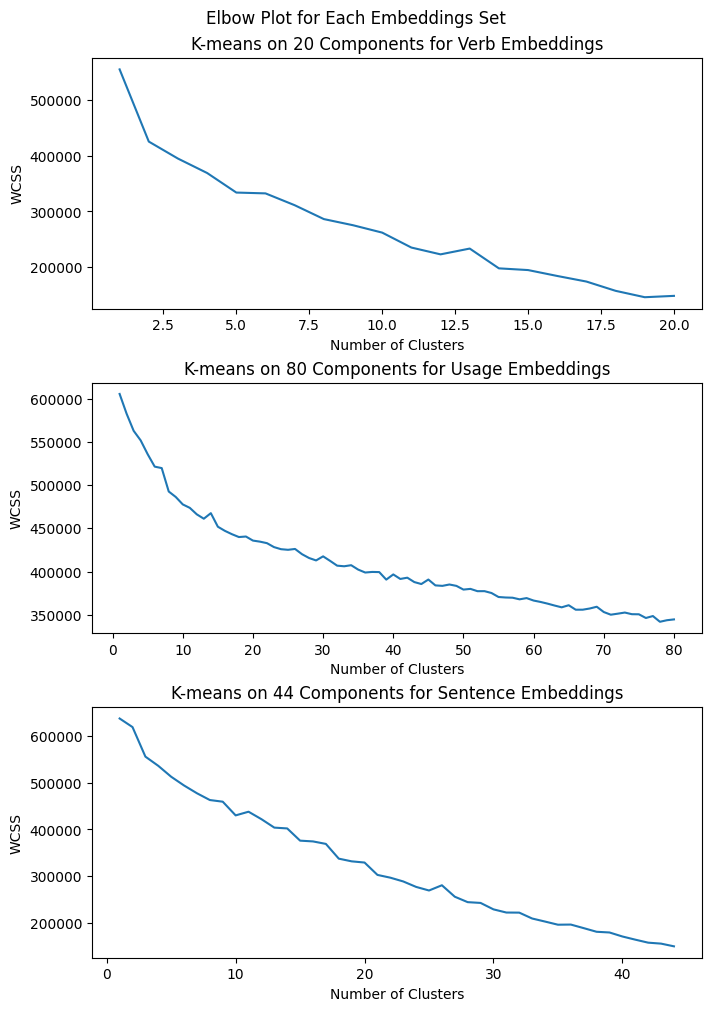

In [20]:

def PlotClusters(df, ax:np.ndarray, components: int, title:str):
    df = pd.DataFrame(PCA(n_components=components).fit(scaler.fit_transform(df)).transform(scaler.fit_transform(df)))
    wcss = []
    for i in range(1, components+1):
        model = KMeans(n_clusters=i, init="k-means++")
        model.fit(df)
        wcss.append(model.inertia_)
        
    ax.plot(range(1, components+1), wcss)
    ax.set_ylabel('WCSS')
    ax.set_xlabel('Number of Clusters')
    ax.set_title(f'K-means on {components} Components for {title} Embeddings')


fig, axs = plt.subplots(3, 1, figsize=(7, 10), layout='constrained')


PlotClusters(df_pca_verb, ax=axs[0], components=20, title='Verb')
PlotClusters(df_pca_usage, ax=axs[1],components=80,title='Usage')
PlotClusters(df_pca_sentence, ax=axs[2],components=44,title='Sentence')

# axs[1].set_xlim(0,30)
# axs[2].set_xlim(0,10)

plt.suptitle('Elbow Plot for Each Embeddings Set')
plt.show()

From the graph of WCSS, it's hard to tell what number of clusters are optimal for the second two embeddings. We will proceed with Silhouette scores.

#### Silhouette Analysis

Optimal K for: 
Verb: 2 (score: 0.443)
Usage: 18 (score: 0.089)
Sentence: 44 (score: 0.568)


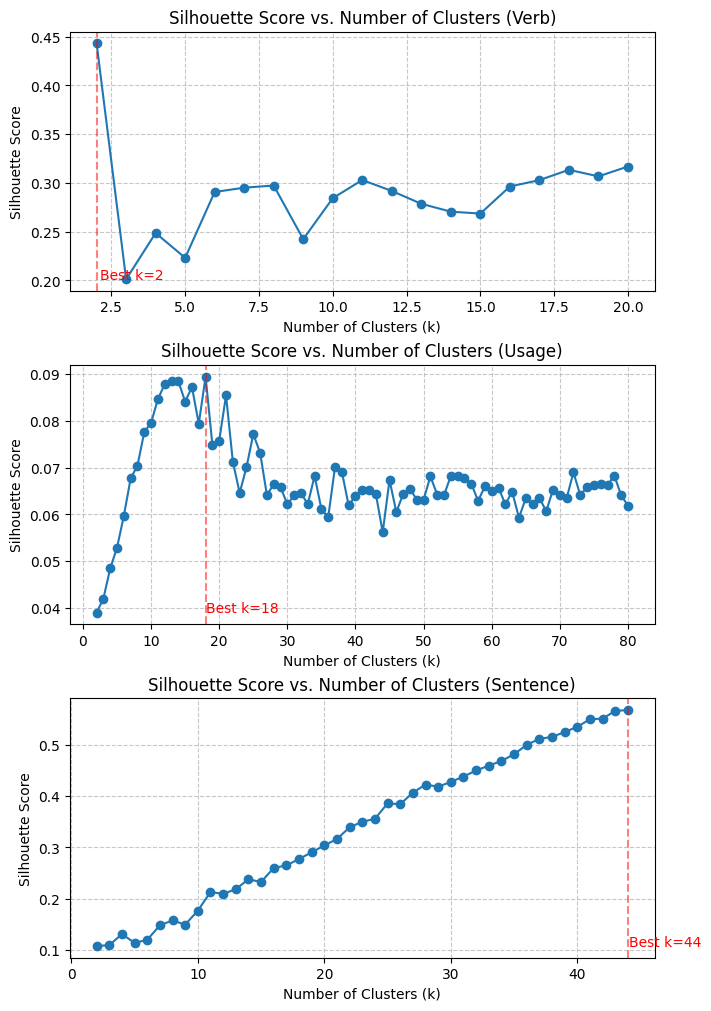

In [21]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
fig, axs = plt.subplots(3, 1, figsize=(7, 10), layout='constrained')
scaler = StandardScaler()

def GenerateClusterSilhouette(df, max_clusters, ax, title):
    best_k, best_score = 2, -1 
    scores = []
    pca_df = pd.DataFrame(PCA(n_components=max_clusters).fit(scaler.fit_transform(df)).transform(scaler.fit_transform(df)))
    
    for k in range(2, max_clusters + 1):
        # For reporoducibility
        model = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
        labels = model.fit_predict(pca_df)
        
        # Check if we have enough samples for silhouette score
        if len(np.unique(labels)) > 1:  
            score = silhouette_score(pca_df, labels)
            scores.append(score)
            
            if score > best_score:
                best_k, best_score = k, score
        else:
            scores.append(0)  
    
    
    ax.plot(range(2, max_clusters + 1), scores, marker='o')
    ax.set_xlabel("Number of Clusters (k)")
    ax.set_ylabel("Silhouette Score")
    ax.set_title(f"Silhouette Score vs. Number of Clusters ({title})")
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Best K
    ax.axvline(x=best_k, color='r', linestyle='--', alpha=0.5)
    ax.text(best_k+0.1, min(scores), f'Best k={best_k}', color='r')
    
    return best_k, best_score

# Use different dataframes for each analysis
verb_k, verb_score = GenerateClusterSilhouette(df_pca_verb, max_clusters=20, ax=axs[0], title='Verb')
usage_k, usage_score = GenerateClusterSilhouette(df_pca_usage, ax=axs[1], max_clusters=80, title='Usage')
sentence_k, sentence_score = GenerateClusterSilhouette(df_pca_sentence, ax=axs[2], max_clusters=44, title='Sentence')

print(f'Optimal K for: \nVerb: {verb_k} (score: {verb_score:.3f})\nUsage: {usage_k} (score: {usage_score:.3f})\nSentence: {sentence_k} (score: {sentence_score:.3f})')

plt.show()

### Generate Finalized PCA-Guided K-means Columns

In [22]:
def GenerateGuidedPCA(df,components:int, clusters:int, title,) -> pd.DataFrame:
    pca_df = pd.DataFrame(PCA(n_components=components).fit(scaler.fit_transform(df)).transform(scaler.fit_transform(df)))
    kmeans_model = KMeans(n_clusters=clusters, init="k-means++")
    labels = kmeans_model.fit_predict(pca_df)
    for i in pca_df.columns:
        pca_df.rename(columns={i:f'{title} component {i+1}'}, inplace=True)
    pca_df.insert(0,f'Kmeans {title} Cluster', labels)
    return pca_df

final_pca_verb = GenerateGuidedPCA(df_pca_verb, components=20, clusters=5, title='Verb')
final_pca_usage = GenerateGuidedPCA(df_pca_usage, components=80, clusters=17, title='Usage')
final_pca_sentence = GenerateGuidedPCA(df_pca_sentence, components=44, clusters=44, title='Sentence')

In [23]:
final_pca_verb.iloc[:,1:]

,Verb component 1,Verb component 2,Verb component 3,Verb component 4,Verb component 5,Verb component 6,Verb component 7,Verb component 8,Verb component 9,Verb component 10,Verb component 11,Verb component 12,Verb component 13,Verb component 14,Verb component 15,Verb component 16,Verb component 17,Verb component 18,Verb component 19,Verb component 20
0,-26.711454,1.712015,12.865347,-7.906755,-2.223977,-6.321424,-5.937448,9.079525,5.291194,-10.410843,2.399456,-4.491580,0.522045,-0.282448,-1.237435,15.125357,-1.777228,4.074045,3.168059,2.376887
1,-26.711454,1.712015,12.865347,-7.906755,-2.223977,-6.321424,-5.937448,9.079525,5.291194,-10.410843,2.399456,-4.491580,0.522045,-0.282448,-1.237435,15.125357,-1.777228,4.074045,3.168059,2.376887
2,3.423143,9.692854,-3.467206,0.155906,1.790098,7.443566,-11.795944,2.526675,-0.824789,3.049224,-4.657421,-1.830781,-1.133687,-6.658966,-7.350789,-5.886939,1.243269,-5.311646,1.451763,0.288246
3,3.423143,9.692854,-3.467206,0.155906,1.790098,7.443566,-11.795944,2.526675,-0.824789,3.049224,-4.657421,-1.830781,-1.133687,-6.658966,-7.350789,-5.886939,1.243269,-5.311646,1.451763,0.288246
4,4.652967,5.479965,-9.088546,-0.591907,4.575036,-3.531623,4.511590,-9.239050,14.020182,-5.064314,6.978105,-5.357333,1.137063,-6.800872,0.834618,-2.611795,0.594775,6.776231,7.320343,-0.011205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,5.501118,-4.002540,3.569596,-2.662463,-1.578265,-4.543288,-0.957234,0.139124,0.648064,-1.122858,1.875119,-4.502932,-2.344242,1.155278,-1.524206,0.262157,1.399359,0.137541,-0.704252,-2.085305
956,-33.162599,-2.471321,12.515673,-4.713638,10.289730,-1.320731,15.272730,4.745495,-13.384324,7.507890,-0.516709,-5.895148,-7.741792,-7.843984,-7.495676,-7.133904,-4.580936,10.574729,1.830300,3.229809
957,-33.162599,-2.471321,12.515673,-4.713638,10.289730,-1.320731,15.272730,4.745495,-13.384324,7.507890,-0.516709,-5.895148,-7.741792,-7.843984,-7.495676,-7.133904,-4.580936,10.574729,1.830300,3.229809
958,3.861410,-3.757650,5.842905,-0.123505,-7.746934,-6.777625,5.785171,-5.871844,-0.107664,-2.089615,-12.600301,-1.511390,3.497493,7.978123,-5.422878,-2.375664,0.843844,-2.592800,9.053134,7.303762


In [24]:
df_pca_kmeans =  pd.concat([final_pca_usage, final_pca_verb, final_pca_sentence], axis=1)
df_pca_kmeans

,Kmeans Usage Cluster,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,Usage component 6,Usage component 7,Usage component 8,Usage component 9,...,Sentence component 35,Sentence component 36,Sentence component 37,Sentence component 38,Sentence component 39,Sentence component 40,Sentence component 41,Sentence component 42,Sentence component 43,Sentence component 44
0,5,-8.374916,4.728457,7.423255,-2.966206,-5.741022,-8.139380,1.290093,0.989337,2.106650,...,-0.317780,1.115619,-2.678022,-5.409123,0.076722,-1.213849,-4.246872,3.459479,-0.417361,2.274904
1,4,2.050853,-4.892994,-2.822290,-3.032775,5.183069,-5.859356,0.391784,0.519463,-4.313498,...,-0.317780,1.115619,-2.678022,-5.409123,0.076722,-1.213849,-4.246872,3.459479,-0.417361,2.274904
2,7,7.252717,1.756598,7.908640,5.816270,0.834686,2.075637,-4.142787,-0.722993,-2.297251,...,0.467035,0.432599,1.023420,-0.266993,-0.294180,0.619137,0.287891,1.484848,1.178540,0.032877
3,11,-1.302575,1.373769,-10.023007,0.549129,-1.348097,2.357321,-0.437133,-5.101332,-0.022274,...,0.467035,0.432599,1.023420,-0.266993,-0.294180,0.619137,0.287891,1.484848,1.178540,0.032877
4,2,-9.532715,6.900548,3.117294,-4.408847,-5.571524,-7.805081,-6.222161,2.248195,-6.119150,...,-2.989370,-0.942013,0.885564,0.337612,1.915323,4.948066,2.806636,-1.168656,-4.333482,-0.385135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
955,12,6.415037,-2.337795,0.826203,-6.325686,5.834112,-5.584866,7.134195,-4.162917,10.382753,...,1.710042,1.493535,-0.980178,2.799687,0.198948,0.306221,1.842021,-0.432426,-0.035297,1.514199
956,15,0.548264,-8.432915,-0.918613,10.396083,-7.156237,-2.145032,0.092555,-5.370585,3.117897,...,-1.755521,6.057795,-0.273987,3.348095,0.443092,3.754888,5.850622,-4.523288,2.532462,-0.600315
957,6,-8.143210,1.336252,-2.392004,-6.525645,5.521117,3.105543,-4.876512,-6.886378,-0.763305,...,-1.755521,6.057795,-0.273987,3.348095,0.443092,3.754888,5.850622,-4.523288,2.532462,-0.600315
958,7,5.988908,7.567224,8.668148,-1.894413,0.745390,0.523626,4.231458,-1.773342,7.856080,...,-1.640805,-2.163635,-3.422429,-0.989177,-0.511367,0.146219,-3.571827,-3.189557,1.352935,-0.267413


In [25]:
df_pca_kmeans.to_excel(
    '../../Dataset/Ensemble/PCA_Guided_Kmeans.xlsx', index=False)

### Checkpoint for PCA-Kmeans

In [26]:
df_pca_kmeans = pd.read_excel(
    '../../Dataset/Ensemble/PCA_Guided_Kmeans.xlsx')
df_pca_kmeans.head()

,Kmeans Usage Cluster,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,Usage component 6,Usage component 7,Usage component 8,Usage component 9,...,Sentence component 35,Sentence component 36,Sentence component 37,Sentence component 38,Sentence component 39,Sentence component 40,Sentence component 41,Sentence component 42,Sentence component 43,Sentence component 44
0,5,-8.374916,4.728457,7.423255,-2.966206,-5.741022,-8.139380,1.290093,0.989337,2.106650,...,-0.317780,1.115619,-2.678022,-5.409123,0.076722,-1.213849,-4.246872,3.459479,-0.417361,2.274904
1,4,2.050853,-4.892994,-2.822290,-3.032775,5.183069,-5.859356,0.391784,0.519463,-4.313498,...,-0.317780,1.115619,-2.678022,-5.409123,0.076722,-1.213849,-4.246872,3.459479,-0.417361,2.274904
2,7,7.252717,1.756598,7.908640,5.816270,0.834686,2.075637,-4.142787,-0.722993,-2.297251,...,0.467035,0.432599,1.023420,-0.266993,-0.294180,0.619137,0.287891,1.484848,1.178540,0.032877
3,11,-1.302575,1.373769,-10.023007,0.549129,-1.348097,2.357321,-0.437133,-5.101332,-0.022274,...,0.467035,0.432599,1.023420,-0.266993,-0.294180,0.619137,0.287891,1.484848,1.178540,0.032877
4,2,-9.532715,6.900548,3.117294,-4.408847,-5.571524,-7.805081,-6.222161,2.248195,-6.119150,...,-2.989370,-0.942013,0.885564,0.337612,1.915323,4.948066,2.806636,-1.168656,-4.333482,-0.385135


## Classification Models


### Combining PCA Guided KMeans with Original Dataset

In [27]:
df_embedded = pd.read_excel(
    '../../Dataset/Ensemble/train_with_embeddings.xlsx')
df_embedded.head(1)
display(df_embedded)

,FOS,Word Sense,Verb,Usage,Is FOS,Sentence Embeddings,Verb Embeddings,Usage Embeddings,Similarity Scores
0,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']","Si Pedro kakha tuka, walay savings ug pirmi la...",1,[ 3.48086096e-02 -3.99009064e-02 1.22562805e-...,[ 3.33587779e-03 -1.31168393e-02 -5.84905334e-...,[-0.06521839 -0.01156479 -0.07741037 0.038842...,tensor([[0.1349]])
1,kakha tuka,kamot-sa-lubong,"['kakha', 'tuka']",Ang langgam nagkakha tuka sa yuta aron makakao...,0,[ 3.48086096e-02 -3.99009064e-02 1.22562805e-...,[ 3.33587779e-03 -1.31168393e-02 -5.84905334e-...,[-6.56474158e-02 7.02367688e-04 -1.01659857e-...,tensor([[0.1166]])
2,ipanabi na sa clouds,Isulti kana sa mga marine,['ipanabi'],Ang mga tawo nga magbuot-buot pirmi lang ipana...,1,[-2.30799001e-02 8.44107755e-03 1.20995091e-...,[-1.96136646e-02 1.01789432e-02 1.20241344e-...,[-0.02670816 -0.06538796 0.04819792 0.006814...,tensor([[0.1359]])
3,ipanabi na sa clouds,Isulti kana sa mga marine,['ipanabi'],Naglingkod si Ana sa atop ug gitan-aw ang pang...,0,[-2.30799001e-02 8.44107755e-03 1.20995091e-...,[-1.96136646e-02 1.01789432e-02 1.20241344e-...,[-5.40964529e-02 3.04708090e-02 -3.47059146e-...,tensor([[0.1716]])
4,dili na nimo mabalik ang baha sa bukid,Ang nahimo nahimo na,['mabalik'],Si Pedro giingnan nga dili na nimo mabalik ang...,1,[ 2.63196733e-02 -5.04106805e-02 -1.52470879e-...,[-4.54647616e-02 -2.01990665e-03 -5.44687221e-...,[-0.03736681 -0.01602739 -0.03805926 0.001367...,tensor([[0.1330]])
...,...,...,...,...,...,...,...,...,...
955,kirig,pag-awhag,['kirig'],Ang bata nagkinirig samtang nagkatawa pag-ayo.,0,[-8.18726979e-03 4.64598760e-02 1.73556240e-...,[ 6.94212504e-03 -2.21958160e-02 -3.15691717e-...,[-5.00240363e-02 1.48002189e-02 1.89001095e-...,tensor([[0.2095]])
956,lapos sa pikas dunggan,sa pagsulod sa usa ka dalunggan ug paggawas sa...,"['lapos', 'dunggan']",Si Maria pirmi lang maglapos ra sa pikas dungg...,1,[-4.94960099e-02 2.53072921e-02 2.12757457e-...,[-2.16433033e-02 4.27883081e-02 -1.80028528e-...,[ 1.95109211e-02 8.77134444e-04 1.06720105e-...,tensor([[0.2071]])
957,lapos sa pikas dunggan,sa pagsulod sa usa ka dalunggan ug paggawas sa...,"['lapos', 'dunggan']","Nagtuo si Juan nga nakadungog siya og hilak, a...",0,[-4.94960099e-02 2.53072921e-02 2.12757457e-...,[-2.16433033e-02 4.27883081e-02 -1.80028528e-...,[-0.02892722 -0.00915153 -0.03936455 -0.037514...,tensor([[0.3138]])
958,dula og panit,sa pag- masturba,['dula'],Ang mga bata nga dula og panit kasagaran wala’...,1,[-4.34120215e-04 -3.22334655e-02 4.91112284e-...,[-3.02006360e-02 -1.57113932e-02 -3.54669057e-...,[-6.18132614e-02 2.44096965e-02 4.91687097e-...,tensor([[0.1666]])


In [28]:
df_train = pd.concat([df_embedded, df_pca_kmeans], axis=1)
df_train.drop(columns=['Sentence Embeddings', 'Verb Embeddings', 'Usage Embeddings'], inplace=True)

# Output

## Load Models & Libraries

In [29]:
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

In [30]:
train_df = df_train
test_df = pd.read_excel("../../Dataset/Test_Set_WLabels.xlsx")

## Tuning & Training of Models

Dropping features that will not be used in svm

#### Train Set

In [31]:
import torch
labels_train = train_df['Is FOS']
X_train_selected = train_df.drop(columns=['Is FOS', 'Word Sense', 'Verb', 'Usage'])

# Further cleaning of tensor string
X_train_selected['Similarity Scores'] = X_train_selected['Similarity Scores'].apply(lambda x: float(torch.tensor(eval(x.replace("tensor", "")))))
display(X_train_selected.head(), labels_train.head())


,FOS,Similarity Scores,Kmeans Usage Cluster,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,Usage component 6,Usage component 7,...,Sentence component 35,Sentence component 36,Sentence component 37,Sentence component 38,Sentence component 39,Sentence component 40,Sentence component 41,Sentence component 42,Sentence component 43,Sentence component 44
0,kakha tuka,0.1349,5,-8.374916,4.728457,7.423255,-2.966206,-5.741022,-8.139380,1.290093,...,-0.317780,1.115619,-2.678022,-5.409123,0.076722,-1.213849,-4.246872,3.459479,-0.417361,2.274904
1,kakha tuka,0.1166,4,2.050853,-4.892994,-2.822290,-3.032775,5.183069,-5.859356,0.391784,...,-0.317780,1.115619,-2.678022,-5.409123,0.076722,-1.213849,-4.246872,3.459479,-0.417361,2.274904
2,ipanabi na sa clouds,0.1359,7,7.252717,1.756598,7.908640,5.816270,0.834686,2.075637,-4.142787,...,0.467035,0.432599,1.023420,-0.266993,-0.294180,0.619137,0.287891,1.484848,1.178540,0.032877
3,ipanabi na sa clouds,0.1716,11,-1.302575,1.373769,-10.023007,0.549129,-1.348097,2.357321,-0.437133,...,0.467035,0.432599,1.023420,-0.266993,-0.294180,0.619137,0.287891,1.484848,1.178540,0.032877
4,dili na nimo mabalik ang baha sa bukid,0.1330,2,-9.532715,6.900548,3.117294,-4.408847,-5.571524,-7.805081,-6.222161,...,-2.989370,-0.942013,0.885564,0.337612,1.915323,4.948066,2.806636,-1.168656,-4.333482,-0.385135


0    1
1    0
2    1
3    0
4    1
Name: Is FOS, dtype: int64

#### Test Set

In [35]:
from EnsembleProcessing import process_embeddings
X_test_selected = pd.concat([process_embeddings(test_df, 0.8), test_df], axis=1)

labels_test = X_test_selected['Is FOS']
X_test_selected.drop(columns=['Is FOS', 'Word Sense', 'Verb', 'Usage'])

# Further cleaning of tensor string
X_test_selected['Similarity Scores'] = X_test_selected['Similarity Scores'].apply(lambda x: x.item())
display(X_test_selected.head(), labels_test.head())

Generating embeddings...


Transforming Usage Embeddings: 100%|██████████| 240/240 [00:01<00:00, 235.13it/s]


UPDATED
Number of components for 80.0% variance:
Verb: 29 components
Usage: 57 components
Sentence: 29 components
Optimal number of clusters:
Verb: 8 clusters
Usage: 2 clusters
Sentence: 8 clusters


,Similarity Scores,Kmeans Usage Cluster,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,Usage component 6,Usage component 7,Usage component 8,...,Sentence component 25,Sentence component 26,Sentence component 27,Sentence component 28,Sentence component 29,FOS,Word Sense,Verb,Usage,Is FOS
0,0.641610,1,7.540442,-0.941182,-2.716294,-1.755108,2.139160,2.083251,1.749161,0.808621,...,0.033488,-1.027734,3.480824,-0.281801,-2.438697,makabuhi og patay,usa ka makapatikod nga bakak o sugilanon,"['makabuhi', 'patay']",Ang mga tawo nga makabuhi og patay kasagaran m...,1
1,0.687046,1,4.302865,-4.717225,-5.882053,0.581517,0.137309,2.004583,-2.154509,2.885139,...,0.033488,-1.027734,3.480823,-0.281802,-2.438696,makabuhi og patay,usa ka makapatikod nga bakak o sugilanon,"['makabuhi', 'patay']",Ang gahum sa dios makaayo ug makabuhi og patay.,0
2,0.639027,1,6.109707,7.840822,0.786417,-0.543913,-1.491994,-1.769070,4.224696,0.249584,...,-1.384041,-0.351920,3.850535,0.349987,-0.466713,hangyo lubo,usa ka hangyo nga gihimo sa ingon nga paagi ng...,"['hangyo', 'lubo']",Ang mga tawo nga hangyo lubo kasagaran magmala...,1
3,0.665558,1,1.511152,-0.257917,-0.694135,1.858635,-0.468909,2.044209,5.086142,-4.409440,...,-1.384040,-0.351921,3.850536,0.349991,-0.466717,hangyo lubo,usa ka hangyo nga gihimo sa ingon nga paagi ng...,"['hangyo', 'lubo']","""Ang bata miadtos sapa ug nangayo og hangyo lu...",0
4,0.572981,1,0.201206,-0.182906,-0.179610,0.441289,0.881107,-1.565249,0.674359,2.610724,...,4.518917,-1.497276,0.762567,1.695526,0.291796,molayag sa kalipay,sa pagpakigsekso,['molayag'],Ang mga kabatan-onan nagmolayag sa kalipay hum...,1


0    1
1    0
2    1
3    0
4    1
Name: Is FOS, dtype: int64

### Pipelines for both models

Preprocessing step turns the only non-numerical (FOS) column to tf-idf representations instead of going back to turn it into embeddings

In [36]:
X_train_selected.shape, labels_train.shape

((960, 149), (960,))

Preprocessor step of pipeline

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def GetTextCol(X):
    text_cols = X.select_dtypes(include=['object', 'string']).columns
    if len(text_cols) == 0:
        raise ValueError("No text columns found in input DataFrame")
    # Error is raised if the first index is not returned.
    return text_cols[0]

def GetNumCol(X):
    return X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(), GetTextCol),
        ("scaler", StandardScaler(), GetNumCol)
    ],
    remainder='drop'  # Remove any unhandled columns
)

### Hyperparmeters and Training

#### Helper function for Alignment
- The way our implementation is set, the preprocessing step for generating embeddings outputs a different quantity of component columns for each dataset.
- The disadvantage of this approach is that we're unable to feed a disalignment between the quantity of columns for a hypothetical test set and train set.
- The workaround to this approach is completely removing extra columns from the bigger dataset.

In [38]:
def align_all_components(df1, df2):
    group_prefixes = ["Usage component", "Verb component", "Sentence component"]
    
    # Identify non-component columns and differences
    non_component = lambda df: {c for c in df.columns if not any(p in c for p in group_prefixes)}
    nc1, nc2 = non_component(df1), non_component(df2)
    if diff := nc1 ^ nc2:
        print(f"Extra non-component columns: {list(diff)}")
    
    # Align component columns
    aligned_parts1, aligned_parts2, col_lost = [], [], {}
    for prefix in group_prefixes:
        cols1 = [c for c in df1 if c.startswith(prefix)]
        cols2 = [c for c in df2 if c.startswith(prefix)]
        min_len = min(len(cols1), len(cols2))
        col_lost[prefix] = abs(len(cols1) - len(cols2))
        aligned_parts1.append(df1[cols1[:min_len]])
        aligned_parts2.append(df2[cols2[:min_len]])
    
    # Combine aligned components and common non-component columns
    common_nc = list(nc1 & nc2)
    aligned_df1 = pd.concat([df1[common_nc]] + aligned_parts1, axis=1)
    aligned_df2 = pd.concat([df2[common_nc]] + aligned_parts2, axis=1)
    
    # Ensure "FOS column" is first. Does not checck anymore if FOS exists.
    def reorder_fos_first(df):
        cols = df.columns.tolist()
        cols.remove("FOS")
        cols.insert(0, "FOS")
        return df[cols]
    
    aligned_df1 = reorder_fos_first(aligned_df1)
    aligned_df2 = reorder_fos_first(aligned_df2)
    
    print(f"\nLost columns: {col_lost}")
    return aligned_df1, aligned_df2

Applying alignment before entering the pipeline


In [39]:
aligned_X_train_selected, aligned_X_test_selected = align_all_components(X_train_selected,X_test_selected.drop(columns=['Verb', 'Word Sense', 'Usage', 'Is FOS']))
display(
    aligned_X_train_selected.head(), aligned_X_test_selected.head()
)


Lost columns: {'Usage component': 23, 'Verb component': 9, 'Sentence component': 15}


,FOS,Kmeans Usage Cluster,Kmeans Sentence Cluster,Kmeans Verb Cluster,Similarity Scores,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,...,Sentence component 20,Sentence component 21,Sentence component 22,Sentence component 23,Sentence component 24,Sentence component 25,Sentence component 26,Sentence component 27,Sentence component 28,Sentence component 29
0,kakha tuka,5,42,3,0.1349,-8.374916,4.728457,7.423255,-2.966206,-5.741022,...,-1.747138,-3.176249,0.198332,-0.457522,4.703791,-2.372931,-1.520540,1.913682,2.173962,3.287864
1,kakha tuka,4,42,3,0.1166,2.050853,-4.892994,-2.822290,-3.032775,5.183069,...,-1.747138,-3.176249,0.198332,-0.457522,4.703791,-2.372931,-1.520540,1.913682,2.173962,3.287864
2,ipanabi na sa clouds,7,14,0,0.1359,7.252717,1.756598,7.908640,5.816270,0.834686,...,4.491486,3.580536,0.486547,-1.590408,-1.121385,-5.140061,2.117996,-1.615486,-6.371272,1.484156
3,ipanabi na sa clouds,11,14,0,0.1716,-1.302575,1.373769,-10.023007,0.549129,-1.348097,...,4.491486,3.580536,0.486547,-1.590408,-1.121385,-5.140061,2.117996,-1.615486,-6.371272,1.484156
4,dili na nimo mabalik ang baha sa bukid,2,24,0,0.1330,-9.532715,6.900548,3.117294,-4.408847,-5.571524,...,3.189981,-4.208182,-2.311872,-0.391426,5.927242,-1.745197,-4.074724,4.412594,0.240283,-1.091247


,FOS,Kmeans Usage Cluster,Kmeans Sentence Cluster,Kmeans Verb Cluster,Similarity Scores,Usage component 1,Usage component 2,Usage component 3,Usage component 4,Usage component 5,...,Sentence component 20,Sentence component 21,Sentence component 22,Sentence component 23,Sentence component 24,Sentence component 25,Sentence component 26,Sentence component 27,Sentence component 28,Sentence component 29
0,makabuhi og patay,1,1,2,0.641610,7.540442,-0.941182,-2.716294,-1.755108,2.139160,...,2.365830,0.941818,1.122858,1.374194,-0.462427,0.033488,-1.027734,3.480824,-0.281801,-2.438697
1,makabuhi og patay,1,1,2,0.687046,4.302865,-4.717225,-5.882053,0.581517,0.137309,...,2.365827,0.941819,1.122858,1.374193,-0.462425,0.033488,-1.027734,3.480823,-0.281802,-2.438696
2,hangyo lubo,1,1,2,0.639027,6.109707,7.840822,0.786417,-0.543913,-1.491994,...,0.352939,0.169401,-1.206730,2.327618,1.342335,-1.384041,-0.351920,3.850535,0.349987,-0.466713
3,hangyo lubo,1,1,2,0.665558,1.511152,-0.257917,-0.694135,1.858635,-0.468909,...,0.352937,0.169400,-1.206731,2.327616,1.342338,-1.384040,-0.351921,3.850536,0.349991,-0.466717
4,molayag sa kalipay,1,2,3,0.572981,0.201206,-0.182906,-0.179610,0.441289,0.881107,...,1.274275,-0.664267,0.063937,0.852517,-0.607520,4.518917,-1.497276,0.762567,1.695526,0.291796


#### Random Forest

In [40]:
# Random Forest pipeline tuning

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("rf", RandomForestClassifier(random_state=42))
])


rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 10, 20]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)

# Fit the full pipeline including preprocessing
rf_grid.fit(aligned_X_train_selected, labels_train)
rf_best_pipeline = rf_grid.best_estimator_
print(f"Best Random Forest parameters: {rf_grid.best_params_}")
print(f"Best F1 score: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best Random Forest parameters: {'rf__max_depth': 20, 'rf__n_estimators': 300}
Best F1 score: 0.9030


#### SVM

In [41]:
# SVM pipeline tuning

svm_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("svm", SVC(random_state=42))
])

svm_param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

svm_grid = GridSearchCV(
    svm_pipeline,
    svm_param_grid,
    cv=5,
    scoring='f1',
    verbose=1
)

# Fit the full pipeline including preprocessing
svm_grid.fit(aligned_X_train_selected, labels_train)
svm_best_pipeline = svm_grid.best_estimator_
print(f"Best SVM parameters: {svm_grid.best_params_}")
print(f"Best F1 score: {svm_grid.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best SVM parameters: {'svm__C': 10, 'svm__kernel': 'rbf'}
Best F1 score: 0.9504


#### Fit both after determining optimal hyperparameters


In [42]:
rf_best_pipeline.fit(aligned_X_train_selected, labels_train)
y_pred_rf  = rf_best_pipeline.predict(aligned_X_test_selected)

svm_best_pipeline.fit(aligned_X_train_selected, labels_train)
y_pred_svm = svm_best_pipeline.predict(aligned_X_test_selected)

In [55]:
rf_best_pipeline.predict(aligned_X_test_selected[0:10])

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

## Evaluation

In [43]:
''' Metrics Formulas
Accuracy = (TN + TP) / (TN + FP + TP + FN)
Precision = TP / (TP + FP)
Recall = TP / (TP + FN)
F1-Score = 2 * (Precision * Recall) / (Precision + Recall)'''

' Metrics Formulas\nAccuracy = (TN + TP) / (TN + FP + TP + FN)\nPrecision = TP / (TP + FP)\nRecall = TP / (TP + FN)\nF1-Score = 2 * (Precision * Recall) / (Precision + Recall)'

In [44]:
# Evaluation for SVM
accuracy_svm = accuracy_score(labels_test, y_pred_svm)
precision_svm = precision_score(labels_test, y_pred_svm)
recall_svm = recall_score(labels_test, y_pred_svm)
f1_svm = f1_score(labels_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(labels_test, y_pred_svm)

print("SVM Model:")
print(f'Accuracy: {accuracy_svm:.4f}')
print(f'Precision: {precision_svm:.4f}')
print(f'Recall: {recall_svm:.4f}')
print(f'F1-Score: {f1_svm:.4f}')
print('Classification Report:\n', classification_report(labels_test, y_pred_svm))
print('Confusion Matrix:\n', conf_matrix_svm)

SVM Model:
Accuracy: 0.5292
Precision: 0.5255
Recall: 0.6000
F1-Score: 0.5603
Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.46      0.49       120
           1       0.53      0.60      0.56       120

    accuracy                           0.53       240
   macro avg       0.53      0.53      0.53       240
weighted avg       0.53      0.53      0.53       240

Confusion Matrix:
 [[55 65]
 [48 72]]


In [45]:
# Evaluation for Random Forest
accuracy_rf = accuracy_score(labels_test, y_pred_rf)
precision_rf = precision_score(labels_test, y_pred_rf)
recall_rf = recall_score(labels_test, y_pred_rf)
f1_rf = f1_score(labels_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(labels_test, y_pred_rf)

print("Random Forest Model:")
print(f'Accuracy: {accuracy_rf:.4f}')
print(f'Precision: {precision_rf:.4f}')
print(f'Recall: {recall_rf:.4f}')
print(f'F1-Score: {f1_rf:.4f}')
print('Classification Report:\n', classification_report(labels_test, y_pred_rf))
print('Confusion Matrix:\n', conf_matrix_rf)

Random Forest Model:
Accuracy: 0.6000
Precision: 0.6017
Recall: 0.5917
F1-Score: 0.5966
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.61      0.60       120
           1       0.60      0.59      0.60       120

    accuracy                           0.60       240
   macro avg       0.60      0.60      0.60       240
weighted avg       0.60      0.60      0.60       240

Confusion Matrix:
 [[73 47]
 [49 71]]


In [46]:
# Evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
svm_scores = [
    accuracy_score(labels_test, y_pred_svm),
    precision_score(labels_test, y_pred_svm),
    recall_score(labels_test, y_pred_svm),
    f1_score(labels_test, y_pred_svm)
]
rf_scores = [
    accuracy_score(labels_test, y_pred_rf),
    precision_score(labels_test, y_pred_rf),
    recall_score(labels_test, y_pred_rf),
    f1_score(labels_test, y_pred_rf)
]

# Confusion Matrices
svm_cm = confusion_matrix(labels_test, y_pred_svm)
rf_cm = confusion_matrix(labels_test, y_pred_rf)

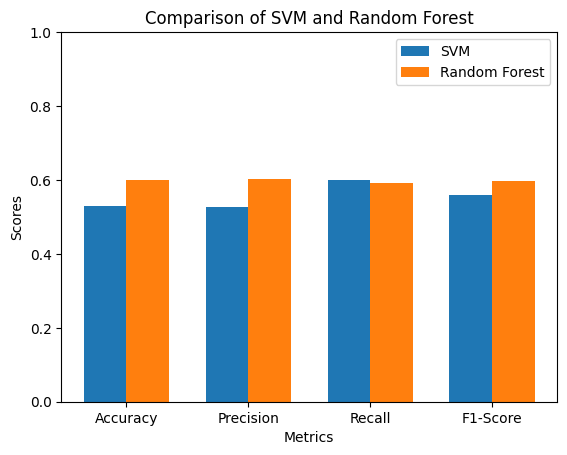

In [47]:
# Plotting the comparison
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, svm_scores, width, label='SVM')
rects2 = ax.bar(x + width/2, rf_scores, width, label='Random Forest')

ax.set_xlabel('Metrics')
ax.set_ylabel('Scores')
ax.set_title('Comparison of SVM and Random Forest')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
plt.ylim(0, 1)
plt.show()

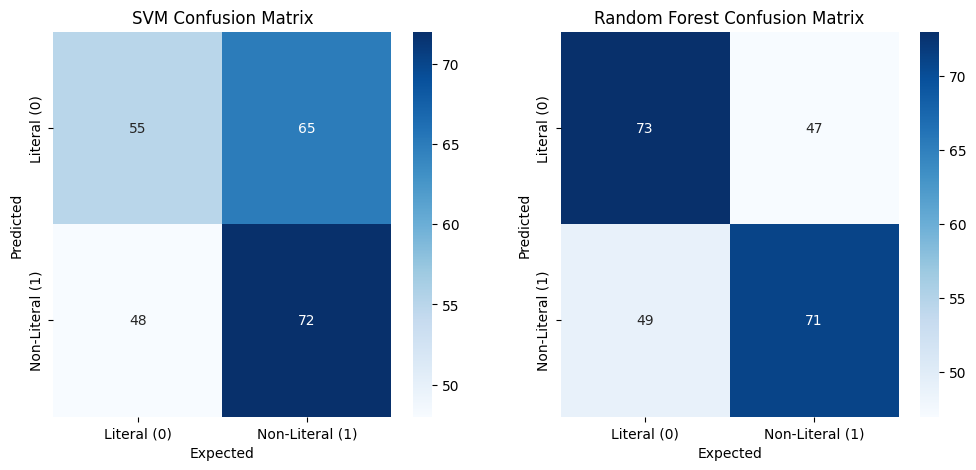

In [48]:
# Plotting confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Literal (0)', 'Non-Literal (1)'], yticklabels=['Literal (0)', 'Non-Literal (1)'], ax=axes[0])
axes[0].set_title('SVM Confusion Matrix')
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Literal (0)', 'Non-Literal (1)'], yticklabels=['Literal (0)', 'Non-Literal (1)'], ax=axes[1])
axes[0].set_ylabel('Predicted')
axes[1].set_ylabel('Predicted')

axes[0].set_xlabel('Expected')
axes[1].set_xlabel('Expected')

axes[1].set_title('Random Forest Confusion Matrix')
plt.show()

## Save models for Inference

In [58]:
import pickle


# SVM
with open('../../Final Implementation/svm_finetuned.pkl','wb') as f:
    pickle.dump(svm_best_pipeline,f)

# Random FOrest
with open('../../Final Implementation/rf_finetuned.pkl','wb') as f:
    pickle.dump(rf_best_pipeline,f)